# EDA Electricity Transformer Dataset (ETDataset)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Carga de los datos
df = pd.read_csv('ETTh1.csv')

In [3]:
# Análisis explotario de los datos
# tamaño del dataset + info
print('Shape del dataset')
print(df.shape)
print(df.info())

# head para ver columnas
print('Columnas del dataset')
print(df.head)

# comprobar tipos de datos
print('Tipo de datos')
print(df.dtypes)

# cantidad de nulos por columna
print('Nulos')
print(df.isnull().sum())

# describe para ver las métricas
print(df.describe())

Shape del dataset
(17420, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB
None
Columnas del dataset
<bound method NDFrame.head of                       date    HUFL   HULL   MUFL   MULL   LUFL   LULL  \
0      2016-07-01 00:00:00   5.827  2.009  1.599  0.462  4.203  1.340   
1      2016-07-01 01:00:00   5.693  2.076  1.492  0.426  4.142  1.371   
2      2016-07-01 02:00:00   5.157  1.741  1.279  0.355  3.777  1.218   
3      2016-07-01 03:00:00   5.090  1.942  1.279  0.391  3.807  1.279   
4      2016-07-01 04

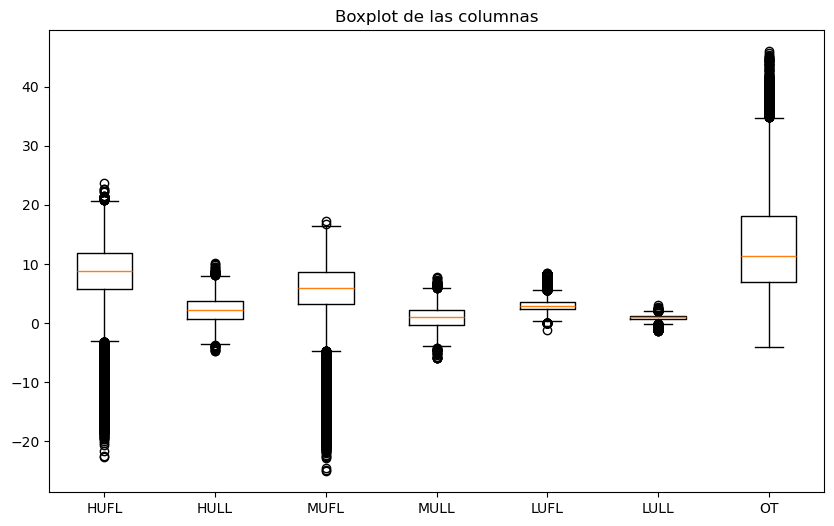

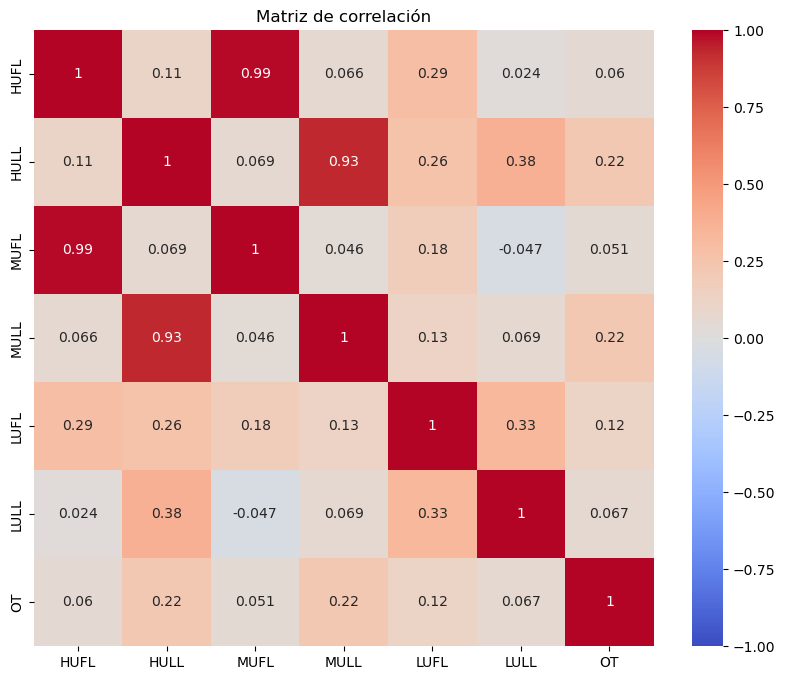

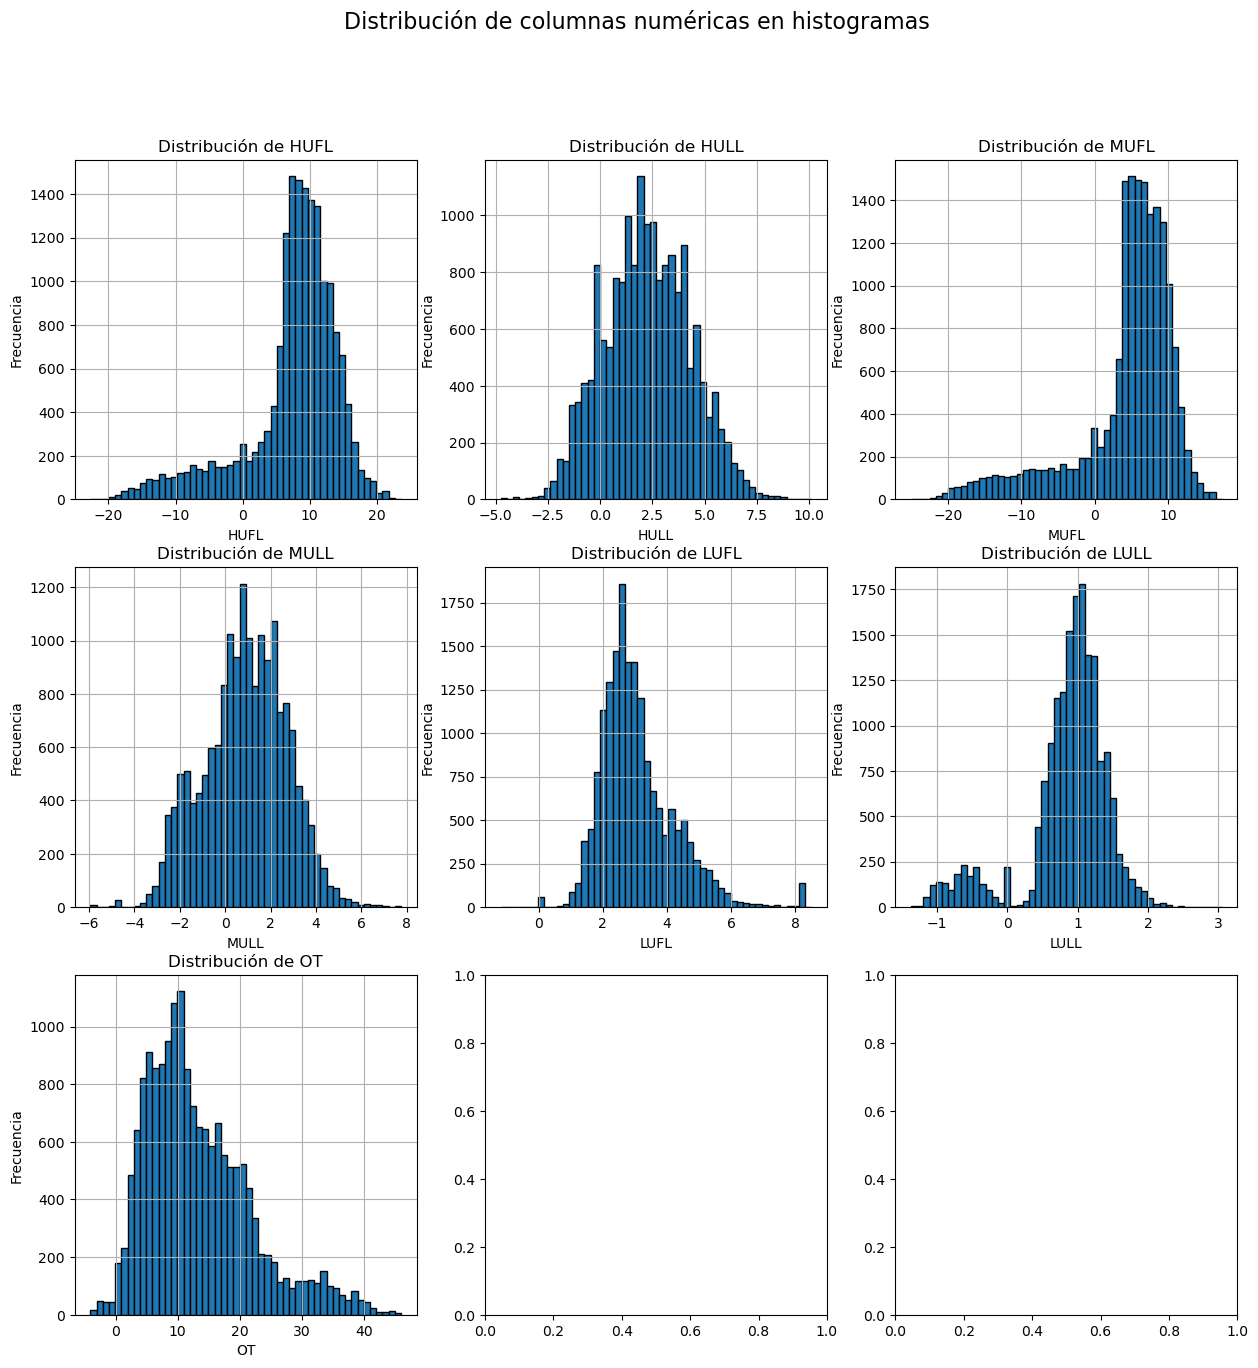

In [4]:
# boxplot para ver la distribución de cada columna, solo columnas float
columnas_num = df.select_dtypes(include=[float])

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(columnas_num.values, tick_labels=columnas_num.columns)

plt.title("Boxplot de las columnas")
plt.show()
        
# matriz de correlación, solo columnas float
matriz = columnas_num.corr()

# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

# Histogramas para tener otra visión
# Calcular el número de filas y columnas para el subplot
n = len(columnas_num)
nrows = 3
ncols = min(n, 3)

# Crear la figura y los subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
fig.suptitle('Distribución de columnas numéricas en histogramas', fontsize=16)

# Aplanar el array de ejes en caso de que sea 2D
axes = axes.flatten() if n > 3 else [axes]

# Crear histogramas para cada variable numérica
for i, col in enumerate(columnas_num):
 ax = axes[i]
 df[col].hist(ax=ax, bins=50, edgecolor='black')
 ax.set_title(f'Distribución de {col}')
 ax.set_xlabel(col)
 ax.set_ylabel('Frecuencia')


date    datetime64[ns]
HUFL           float64
HULL           float64
MUFL           float64
MULL           float64
LUFL           float64
LULL           float64
OT             float64
dtype: object
         HUFL   HULL   MUFL   MULL   LUFL   LULL         OT   año  mes  dia  \
0       5.827  2.009  1.599  0.462  4.203  1.340  30.531000  2016    7    1   
1       5.693  2.076  1.492  0.426  4.142  1.371  27.787001  2016    7    1   
2       5.157  1.741  1.279  0.355  3.777  1.218  27.787001  2016    7    1   
3       5.090  1.942  1.279  0.391  3.807  1.279  25.044001  2016    7    1   
4       5.358  1.942  1.492  0.462  3.868  1.279  21.948000  2016    7    1   
...       ...    ...    ...    ...    ...    ...        ...   ...  ...  ...   
17415  -1.674  3.550 -5.615  2.132  3.472  1.523  10.904000  2018    6   26   
17416  -5.492  4.287 -9.132  2.274  3.533  1.675  11.044000  2018    6   26   
17417   2.813  3.818 -0.817  2.097  3.716  1.523  10.271000  2018    6   26   
17418   9.24

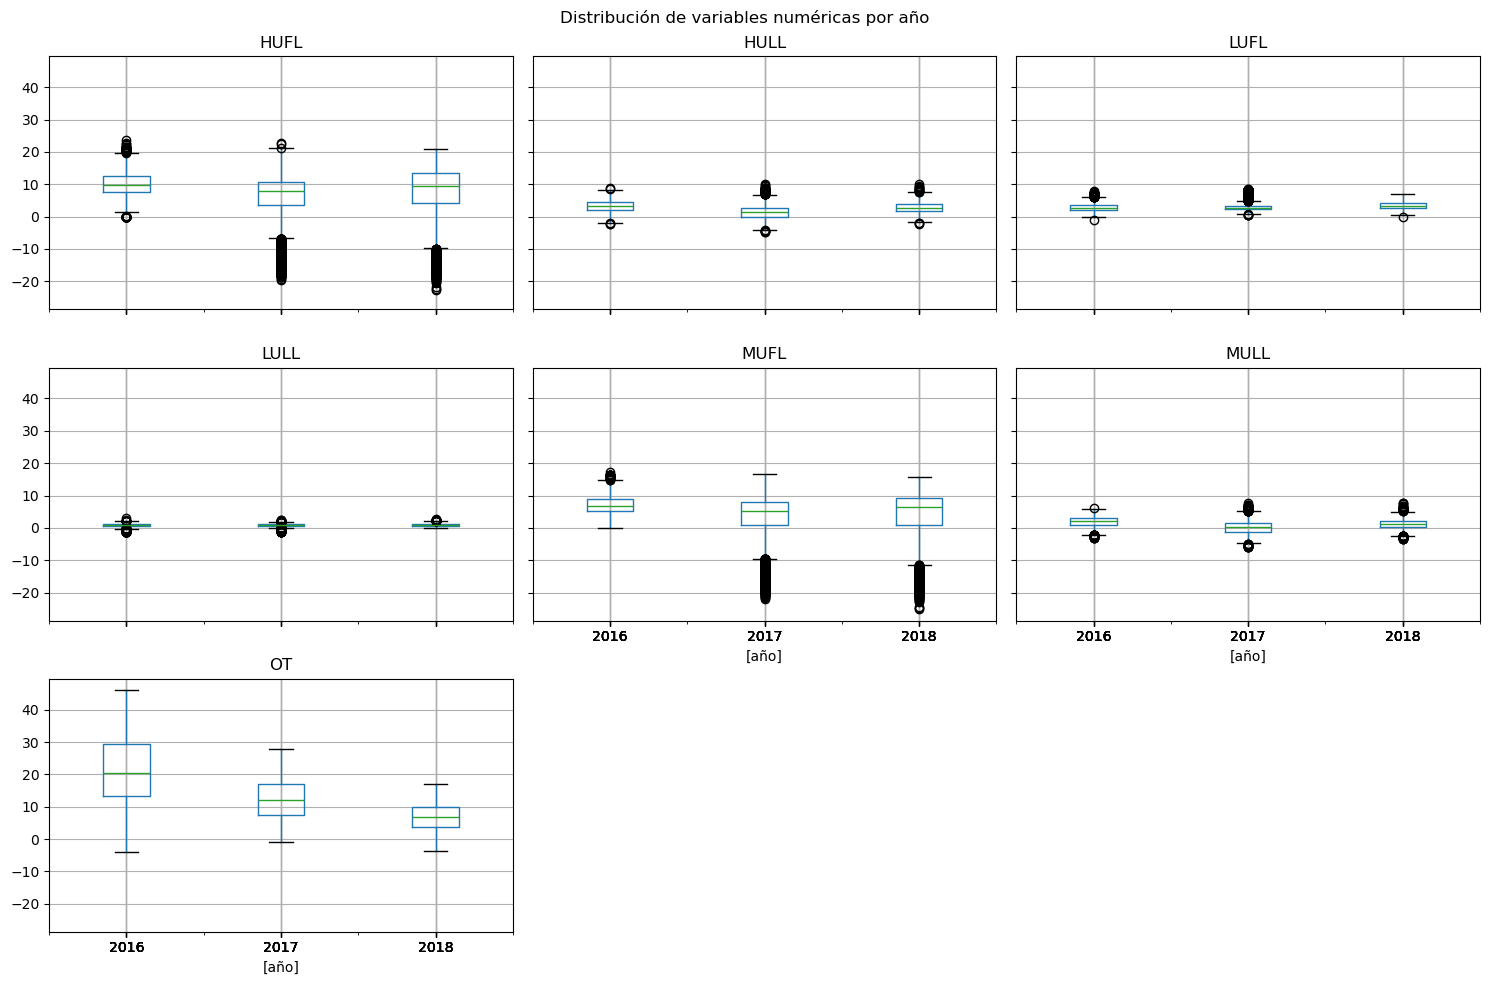

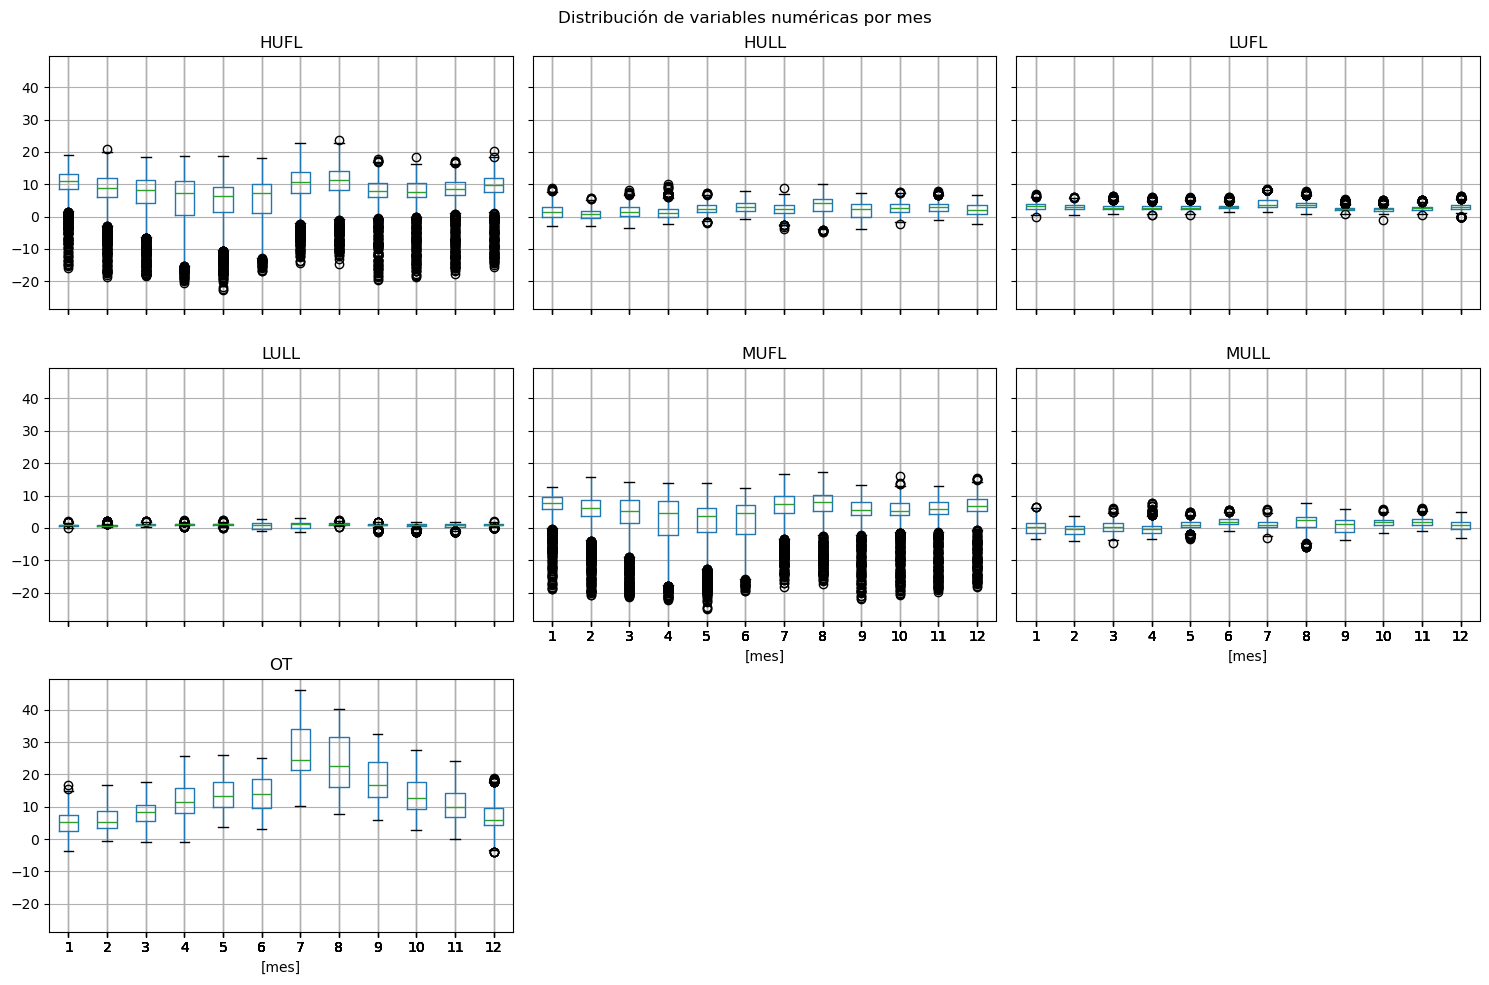

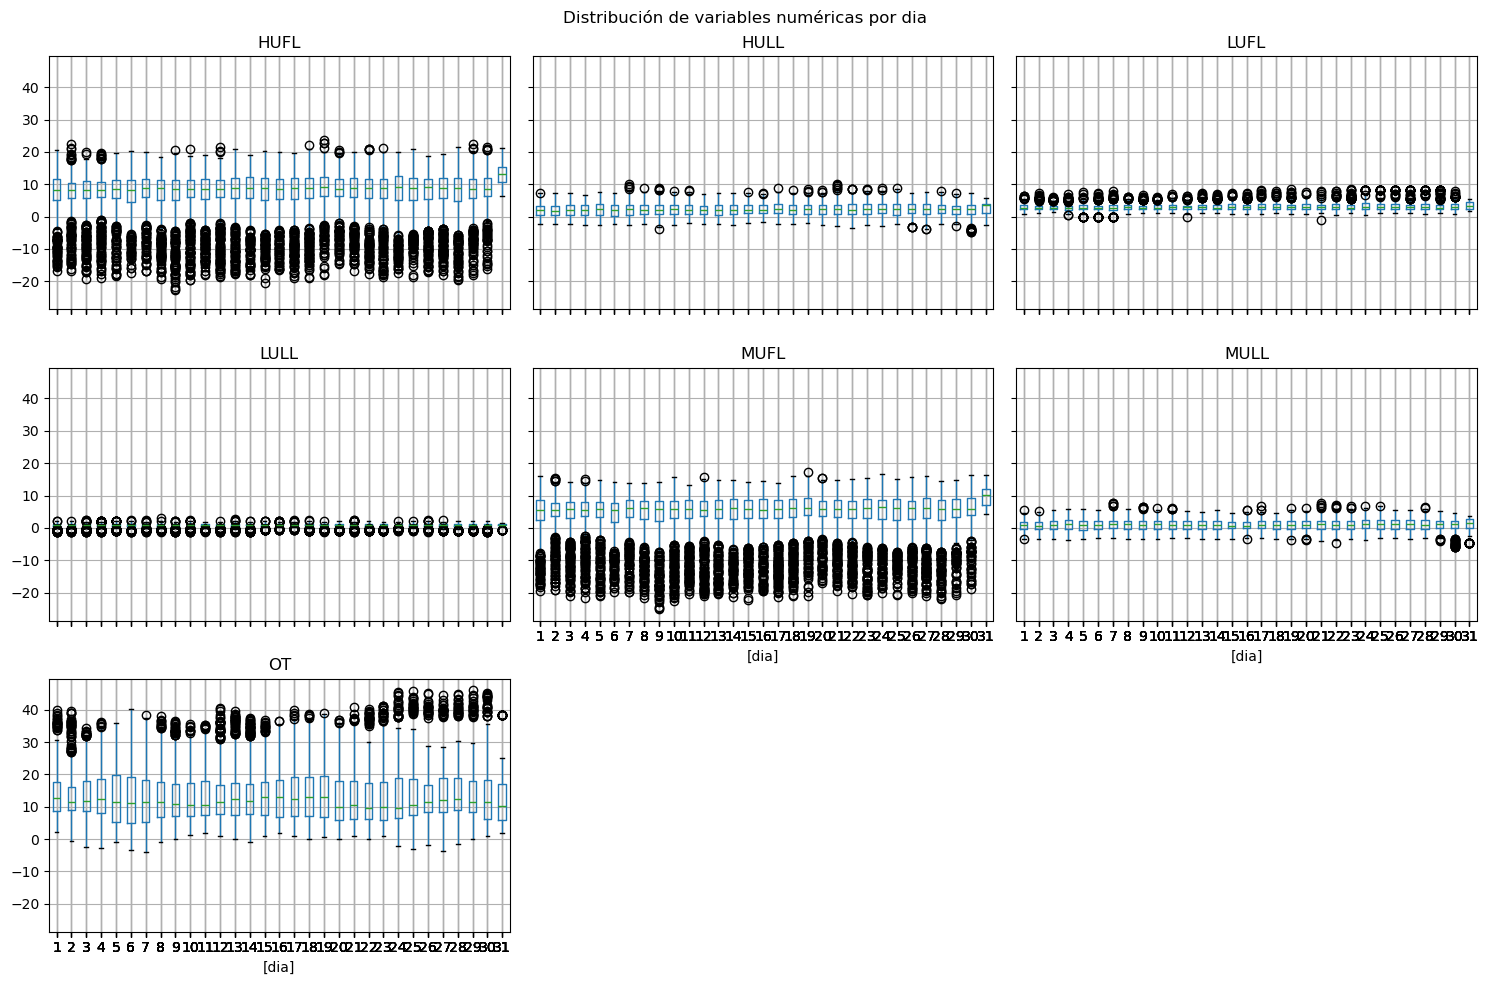

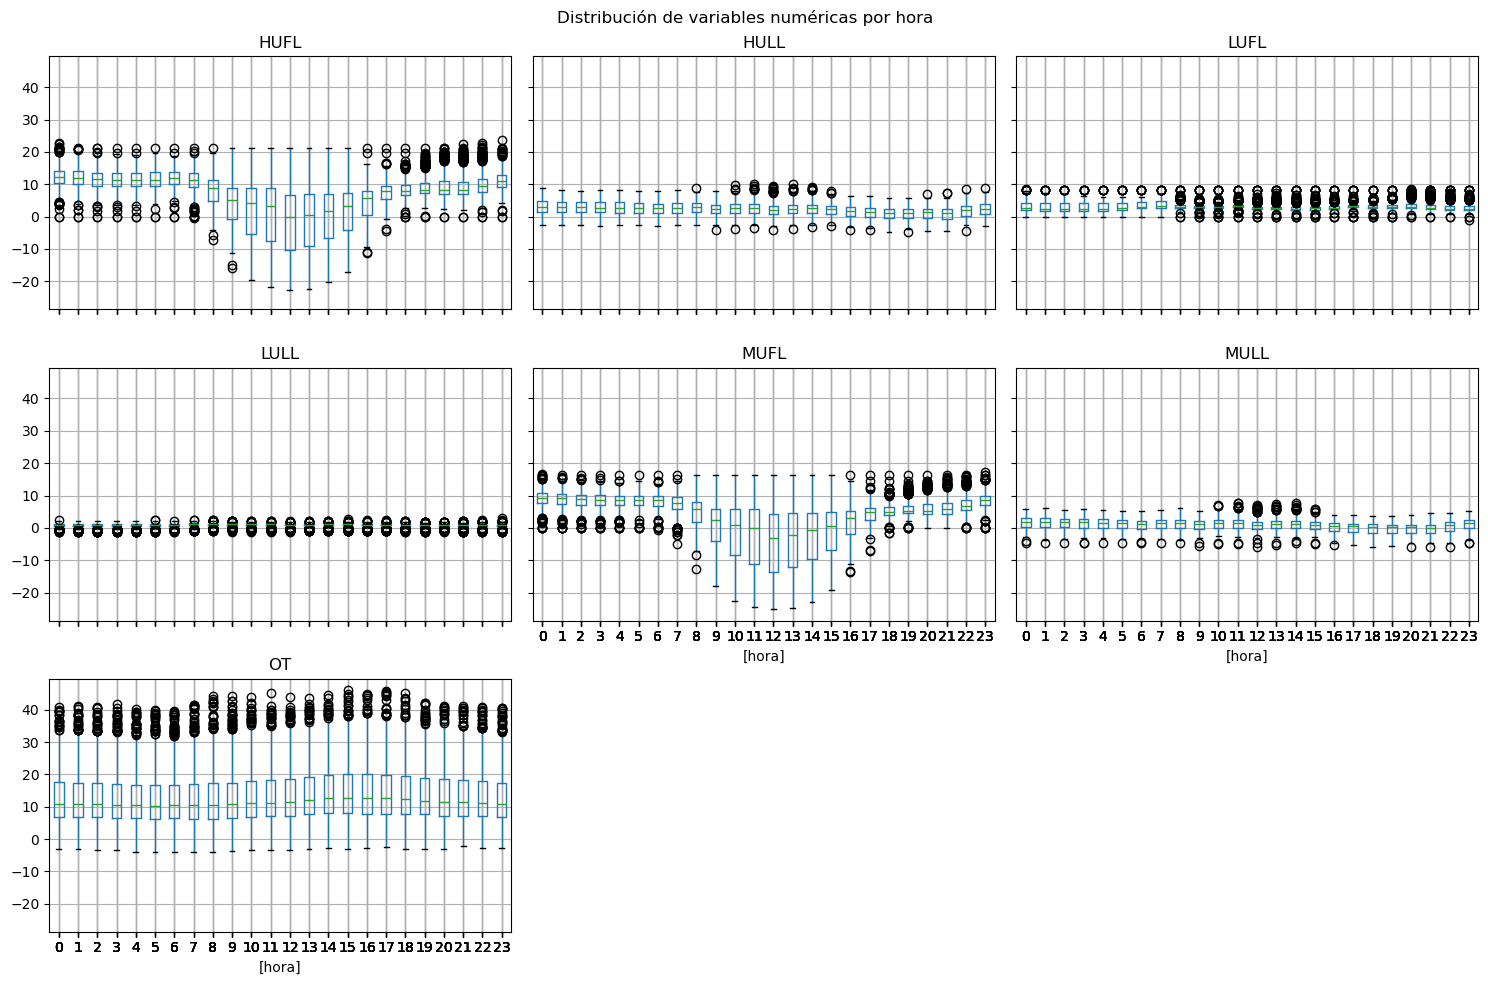

In [5]:
# Visualización por series temporales

# pasamos la columna date a datetime
df_dates = df
df_dates['date'] = pd.to_datetime(df['date'])

# comprobamos
print(df_dates.dtypes)

# dividimos date en horas, dias, meses y años
df_dates['año'] = df['date'].dt.year
df_dates['mes'] = df['date'].dt.month
df_dates['dia'] = df['date'].dt.day
df_dates['hora'] = df['date'].dt.hour

df_dates = df_dates.drop('date', axis=1)

print(df_dates)

# VISUALIZACIÓN POR AÑO
columnas_num_dates = df_dates.select_dtypes(include=['float']).columns.tolist()

columnas_grafico_año = columnas_num_dates + ['año']

df_dates[columnas_grafico_año].boxplot(by='año', figsize=(15, 10), layout=(-1, 3))

plt.suptitle('Distribución de variables numéricas por año')
plt.tight_layout()
plt.show()

# VISUALIZACIÓN POR MES
columnas_grafico_mes = columnas_num_dates + ['mes']

df_dates[columnas_grafico_mes].boxplot(by='mes', figsize=(15, 10), layout=(-1, 3))

plt.suptitle('Distribución de variables numéricas por mes')
plt.tight_layout()
plt.show()

# VISUALIZACIÓN POR DIA
columnas_grafico_dia = columnas_num_dates + ['dia']

df_dates[columnas_grafico_dia].boxplot(by='dia', figsize=(15, 10), layout=(-1, 3))

plt.suptitle('Distribución de variables numéricas por dia')
plt.tight_layout()
plt.show()

# VISUALIZACIÓN POR HORA
columnas_grafico_hora = columnas_num_dates + ['hora']

df_dates[columnas_grafico_hora].boxplot(by='hora', figsize=(15, 10), layout=(-1, 3))

plt.suptitle('Distribución de variables numéricas por hora')
plt.tight_layout()
plt.show()